# Step 5 - Analysis of bicycle network results
## Project: Growing Urban Bicycle Networks with LTNs

This notebook takes the existing infrastructure, the results from 03_poi_based_generation and calculates/analyzes a number of measures:
* cost (length)
* coverage  
* directness  
* efficiency
* overlap with existing networks
* average node degree
* cyclable trips

In [14]:
import fiona

In [1]:
import geopandas as gpd

In [18]:
gdf = gpd.read_file("../../../newcastle_current_ltn_scenario_greedy_demand_weighted (1).gpkg", layer = "newcastle_current_ltn_scenario_greedy_demand_weighted")
gdf.head()

,start_osmid,end_osmid,distance,sp_lts_route,sp_lts_distance,sp_true_distance,eucl_dist,ltn_origin,ltn_destination,start_norm,end_norm,osmid_pair,total_flow,sp_lts_route_str,geometry
0,826287045,1907450682,309.249812,None,1399.457,471.765,309.249812,True,True,826287045,1907450682,None,15.702733,"[826287045, 331882591, 4504609159, 826287015, ...","LINESTRING (-1.62488 54.96771, -1.62136 54.96961)"
1,12091933082,4140896891,366.611193,None,1825.354,1341.165,366.611193,True,True,4140896891,12091933082,None,18.276293,"[12091933082, 12091933083, 12091933092, 120333...","LINESTRING (-1.61558 54.97912, -1.61032 54.98041)"
2,2392633844,12091933082,406.684872,None,955.935,847.536,406.684872,True,True,2392633844,12091933082,None,16.762135,"[2392633844, 11134446, 4415157354, 2169860541,...","LINESTRING (-1.61332 54.97571, -1.61558 54.97912)"
3,29013257,252100827,415.313673,None,3174.817,1326.051,415.313673,True,True,29013257,252100827,None,34.544636,"[29013257, 60150990, 1731802540, 8301427921, 1...","LINESTRING (-1.61430 55.00879, -1.61068 55.01189)"
4,776327170,345643357,481.877848,None,1294.971,677.241,481.877848,True,True,345643357,776327170,None,29.505117,"[776327170, 776327214, 776327226, 4634363980, ...","LINESTRING (-1.58216 54.97811, -1.58948 54.97912)"


In [16]:
fp = "../../../newcastle_current_ltn_scenario_greedy_demand_weighted (1).gpkg"
for layername in fiona.listlayers(fp):
    with fiona.open(fp, layer=layername) as src:
        print(layername, len(src))

newcastle_greedy_demand_weighted 233
newcastle_current_ltn_scenario_greedy_demand_weighted 233


TODO

- Speeding up
    - The `get_composite_lcc_length` funciton is pretty slow currently!
    - Producing buffers for coverage analysis is very slow
    - Coverage very slow - commented out for the moment
    - average node degree very slow
- bikeable trips metric
- find neighbourhoods where large amounts of residiental streets are used to potentially convert to LTNs?
- only runs for one place at at time currently (my bad coding skills + getting stuck down rabbitholes!)

In [3]:
# import libraries
from src import utils
PATH = utils.PATH # shortening the var name so that we don't have to change it below

# System
import csv
import os
import dill as pickle
import itertools
import random
from collections import defaultdict
import pprint
pp = pprint.PrettyPrinter(indent=4)
from tqdm.notebook import tqdm
import glob
from concurrent.futures import ThreadPoolExecutor
from copy import deepcopy
import yaml
import json

# Math/Data
import numpy as np
import pandas as pd


# Network
import networkx as nx

# Plotting
import matplotlib.pyplot as plt
import matplotlib.animation as animation


# Geo
import osmnx as ox
ox.settings.log_file = True
ox.settings.requests_timeout = 300
ox.settings.logs_folder = PATH["logs"]
import geopandas as gpd
import json


## Preliminaries

In [ ]:
debug = False # If True, will produce plots and/or verbose output to double-check
# if not debug: # Only do this if sure the code is bug-free!
#     warnings.filterwarnings('ignore')
rerun_existing = False # If True, will re-run the costly analysis of existing infra even if files already exist.
rerun = False # If True, recompute the analysis. If false, just re-make the plots

In [5]:
params = yaml.load(
    open("../parameters/parameters.yml"), 
    Loader=yaml.FullLoader)
osmnxparameters = json.load(open("../parameters/osmnxparameters.json", "r"))
plotparam = json.load(open("../parameters/plotparam.json", "r"))
plotparam_analysis = json.load(open("../parameters/plotparam_analysis.json", "r"))

### Network weighting by tags

In [6]:
tag_lts = json.load(open("../parameters/tag_lts.json", "r"))
distance_cost = json.load(open("../parameters/distance_cost.json", "r"))

### Load Cities

In [7]:
# load cities
cities = utils.load_cities(PATH, debug)
cities

{'newcastle': {'nominatimstring': 'Newcastle Upon Tyne',
  'countryid': 'gbr',
  'name': 'Newcastle Upon Tyne'}}

## Loading

### Load Results

In [8]:
# betweenness 
betweenness_results = {}
for scenario in params["scenarios"]:
    betweenness_results[scenario] = {}
    for placeid in cities:
        filename = (PATH["results"] + placeid + "/" + scenario + "/" + f"{placeid}_poi_{params['poi_source']}_betweenness_weighted_" + scenario + ".pickle")
        abs_path = os.path.abspath(filename)
        if os.path.exists(abs_path):
            with open(abs_path, "rb") as f:
                betweenness_results[scenario][placeid] = pickle.load(f)
        else:
            print(f"File {abs_path} does not exist.")
            print("Please run the betweenness analysis first.")
            print(f"No betweenness files found for {placeid} in scenario {scenario}.")

In [9]:
# random (many runs to get a distribution)
random_results = {}
for scenario in params["scenarios"]:
    random_results[scenario] = {}
    for placeid in cities:
        pattern = (PATH["results"] + placeid + "/" + scenario + "/" +
                   f"{placeid}_poi_{params['poi_source']}_random_weighted_{scenario}_run*.pickle")
        random_files = sorted(glob.glob(os.path.abspath(pattern)))[:3]  # only take the first 3 whilst we debug :D
        if random_files:
            random_results[scenario][placeid] = []
            for fn in random_files:
                abs_path = os.path.abspath(fn)
                with open(abs_path, "rb") as f:
                    res = pickle.load(f)
                random_results[scenario][placeid].append(res)
        else:
            print(f"No random files found for {placeid} in scenario {scenario}.")
            print("Please run the random growth analysis first.")


In [10]:
# demand
demand_results = {}
for scenario in params["scenarios"]:
    demand_results[scenario] = {}
    for placeid in cities:
        filename = (PATH["results"] + placeid + "/" + scenario + "/" + f"{placeid}_poi_{params['poi_source']}_demand_weighted_" + scenario + ".pickle")
        abs_path = os.path.abspath(filename)
        if os.path.exists(abs_path):
            with open(abs_path, "rb") as f:
                demand_results[scenario][placeid] = pickle.load(f)
        else:
            print(f"File {abs_path} does not exist.")
            print("Please run the demand analysis first.")
            print(f"No demand files found for {placeid} in scenario {scenario}.")


In [11]:
# demand LTN priority
demand_ltn_priority_results = {}
for scenario in params["scenarios"]:
    demand_ltn_priority_results[scenario] = {}
    for placeid in cities:
        filename = (PATH["results"] + placeid + "/" + scenario + "/" + f"{placeid}_poi_{params['poi_source']}_demand_ltn_priority_weighted_" + scenario + ".pickle")
        abs_path = os.path.abspath(filename)
        if os.path.exists(abs_path):
            with open(abs_path, "rb") as f:
                demand_ltn_priority_results[scenario][placeid] = pickle.load(f)
        else:
            print(f"File {abs_path} does not exist.")
            print("Please run the demand LTN priority analysis first.")
            print(f"No demand LTN priority files found for {placeid} in scenario {scenario}.")


In [12]:
# betweenness LTN priority
betweenness_ltn_priority_results = {}
for scenario in params["scenarios"]:
    betweenness_ltn_priority_results[scenario] = {}
    for placeid in cities:
        filename = (PATH["results"] + placeid + "/" + scenario + "/" + f"{placeid}_poi_{params['poi_source']}_betweenness_ltn_priority_weighted_" + scenario + ".pickle")
        abs_path = os.path.abspath(filename)
        if os.path.exists(abs_path):
            with open(abs_path, "rb") as f:
                betweenness_ltn_priority_results[scenario][placeid] = pickle.load(f)
        else:
            print(f"File {abs_path} does not exist.")
            print("Please run the betweenness LTN priority analysis first.")
            print(f"No betweenness LTN priority files found for {placeid} in scenario {scenario}.")


Find investment level, split results into GTs, GT_abstracts 

In [13]:
for scenario_name in params["scenarios"]:
    for placeid in cities:

        # Demand 
        if placeid in demand_results.get(scenario_name, {}):
            demand_dict = demand_results[scenario_name][placeid]
            investment_levels_demand = demand_dict["prune_quantiles"]
            GTs_demand               = demand_dict["GTs"]
            GT_abstracts_demand      = demand_dict["GT_abstracts"]
        else:
            print(f"No demand results for {placeid} in scenario '{scenario_name}'")
            investment_levels_demand = []
            GTs_demand               = []
            GT_abstracts_demand      = []


        # Betweenness‐LTN‐priority 
        if placeid in betweenness_ltn_priority_results.get(scenario_name, {}):
            betweenness_ltn_dict = betweenness_ltn_priority_results[scenario_name][placeid]
            investment_levels_betw = betweenness_ltn_dict["prune_quantiles"]
            GTs_betw               = betweenness_ltn_dict["GTs"]
            GT_abstracts_betw      = betweenness_ltn_dict["GT_abstracts"]
        else:
            # e.g. scenario == "no_ltn_scenario" has no betweenness‐LTN‐priority data
            investment_levels_betw = []
            GTs_betw               = []
            GT_abstracts_betw      = []

        # Betweenness
        if placeid in betweenness_results.get(scenario_name, {}):
            betweenness_dict = betweenness_results[scenario_name][placeid]
            investment_levels_betweenness = betweenness_dict["prune_quantiles"]
            GTs_betweenness               = betweenness_dict["GTs"]
            GT_abstracts_betweenness      = betweenness_dict["GT_abstracts"]
        else:
            investment_levels_betweenness = []
            GTs_betweenness               = []
            GT_abstracts_betweenness      = []

        # Demand‐LTN‐priority 
        if placeid in demand_ltn_priority_results.get(scenario_name, {}):
            dem_ltn_dict = demand_ltn_priority_results[scenario_name][placeid]
            investment_levels_dem_ltn = dem_ltn_dict["prune_quantiles"]
            GTs_dem_ltn               = dem_ltn_dict["GTs"]
            GT_abstracts_dem_ltn      = dem_ltn_dict["GT_abstracts"]
        else:
            investment_levels_dem_ltn = []
            GTs_dem_ltn               = []
            GT_abstracts_dem_ltn      = []

        # Random‐runs (loads all run*.pickle files)
        random_runs_list = random_results.get(scenario_name, {}).get(placeid, [])
        if random_runs_list:
            all_GTs_random       = [run_dict["GTs"]          for run_dict in random_runs_list]
            all_GTabs_random      = [run_dict["GT_abstracts"]  for run_dict in random_runs_list]
            investment_levels_random = random_runs_list[0]["prune_quantiles"]
        else:
            all_GTs_random          = []
            all_GTabs_random         = []
            investment_levels_random = []



### Load existing networks, nodes, GeoDataframe



In [14]:
G_biketracks_dict               = {}  # (placeid, scenario) → biketrack graph
G_biketrack_no_ltns_dict       = {}  # (placeid, scenario) → biketrack_no_ltn graph
G_biketrackcaralls_dict        = {}  # (placeid, scenario) → biketrackcarall graph
G_biketrackcarall_edges_dict    = {}  # (placeid, scenario) → GeoDataFrame of biketrackcarall edges
boundary_gdfs               = {}  # placeid → boundary GeoDataFrame (same for all scenarios)
tess_points_dict            = {}  # (placeid, scenario) → tessellation points GeoDataFrame
ltn_points_dict             = {}  # (placeid, scenario) → LTN points GeoDataFrame
combined_points_dict        = {}  # (placeid, scenario) → combined points GeoDataFrame

for scenario in params["scenarios"]:
    for placeid, placeinfo in cities.items():
        base_folder = os.path.join(PATH["data"], placeid, scenario)

        # Load biketrack graph
        biketrack_gpkg = os.path.join(base_folder, f"{placeid}_biketrack.gpkg")
        if os.path.exists(biketrack_gpkg):
            G_biketrack = utils.ox_gpkg_to_graph(biketrack_gpkg)
            G_biketrack.remove_nodes_from(list(nx.isolates(G_biketrack)))
            G_biketracks_dict[(placeid, scenario)] = G_biketrack
        else:
            print(f"Missing: {biketrack_gpkg}")
            G_biketracks_dict[(placeid, scenario)] = None

        # Load biketrack_no_ltn graph
        biketrack_no_ltn_gpkg = os.path.join(base_folder, f"{placeid}_biketrack_no_ltn.gpkg")
        if os.path.exists(biketrack_no_ltn_gpkg):
            G_no_ltn = utils.ox_gpkg_to_graph(biketrack_no_ltn_gpkg)
            G_no_ltn.remove_nodes_from(list(nx.isolates(G_no_ltn)))
            G_biketrack_no_ltns_dict[(placeid, scenario)] = G_no_ltn
        else:
            print(f"Missing: {biketrack_no_ltn_gpkg}")
            G_biketrack_no_ltns_dict[(placeid, scenario)] = None

        # Load biketrackcarall graph
        biketrackcarall_gpkg = os.path.join(base_folder, f"{placeid}_biketrackcarall.gpkg")
        if os.path.exists(biketrackcarall_gpkg):
            G_carall = utils.ox_gpkg_to_graph(biketrackcarall_gpkg)
            G_carall.remove_nodes_from(list(nx.isolates(G_carall)))
            G_biketrackcaralls_dict[(placeid, scenario)] = G_carall

            # also store edges GeoDataFrame
            edges_gdf = ox.graph_to_gdfs(G_carall, nodes=False)
            G_biketrackcarall_edges_dict[(placeid, scenario)] = edges_gdf
        else:
            print(f"Missing: {biketrackcarall_gpkg}")
            G_biketrackcaralls_dict[(placeid, scenario)] = None
            G_biketrackcarall_edges_dict[(placeid, scenario)] = None

        #  Load boundary once per placeid (it won’t change by scenario)
        if placeid not in boundary_gdfs:
            boundary_gdf = ox.geocode_to_gdf(placeinfo["nominatimstring"])
            boundary_gdfs[placeid] = boundary_gdf

        # get nodes
        tess_points_gpkg = os.path.join(base_folder, f"{placeid}_tessellation_points.gpkg")
        if os.path.exists(tess_points_gpkg):
            tess_points = gpd.read_file(tess_points_gpkg)
            tess_points_dict[(placeid, scenario)] = tess_points
        else:
            print(f"Missing: {tess_points_gpkg}")
            tess_points_dict[(placeid, scenario)] = None
        
        # get ltn points
        if scenario != "no_ltn_scenario":
            ltn_points_gpkg = os.path.join(base_folder, f"{placeid}_ltn_points.gpkg")
            if os.path.exists(ltn_points_gpkg):
                ltn_points = gpd.read_file(ltn_points_gpkg)
                ltn_points_dict[(placeid, scenario)] = ltn_points
            else:
                print(f"Missing: {ltn_points_gpkg}")
                ltn_points_dict[(placeid, scenario)] = None
        
        # get combined points
        combined_points_gpkg = os.path.join(base_folder, f"{placeid}_combined_points.gpkg")
        if os.path.exists(combined_points_gpkg):
            combined_points = gpd.read_file(combined_points_gpkg)
            combined_points_dict[(placeid, scenario)] = combined_points
        else:
            print(f"Missing: {combined_points_gpkg}")
            combined_points_dict[(placeid, scenario)] = None

        # get all neighbourhoods (ragardless of their low traffic status. This doesn't change by scenario)
        all_neighbourhoods = gpd.read_file(PATH["data"] + placeid + "/" + 'neighbourhoods_'+  placeid + '.gpkg')
        all_neighbourhoods_centroids = all_neighbourhoods.geometry.centroid
        all_neighbourhoods_centroids = gpd.GeoDataFrame(geometry= all_neighbourhoods_centroids, crs=all_neighbourhoods.crs)



Missing: ../../bikenwgrowth_external/data/newcastle/no_ltn_scenario/newcastle_tessellation_points.gpkg


/var/folders/66/3jkth_7d5gggg6pyr8yywwt40000gn/T/ipykernel_40880/1656686378.py:84: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_neighbourhoods_centroids = all_neighbourhoods.geometry.centroid


Missing: ../../bikenwgrowth_external/data/newcastle/current_ltn_scenario/newcastle_tessellation_points.gpkg


/var/folders/66/3jkth_7d5gggg6pyr8yywwt40000gn/T/ipykernel_40880/1656686378.py:84: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_neighbourhoods_centroids = all_neighbourhoods.geometry.centroid


Missing: ../../bikenwgrowth_external/data/newcastle/more_ltn_scenario/newcastle_tessellation_points.gpkg


/var/folders/66/3jkth_7d5gggg6pyr8yywwt40000gn/T/ipykernel_40880/1656686378.py:84: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  all_neighbourhoods_centroids = all_neighbourhoods.geometry.centroid


In [15]:
# setup

def csv_to_ox(p, placeid, parameterid):
    '''
    Load graph from csv files (nodes and edge)
    Include OSMID, length, highway, x, y attributes
    '''

    prefix = placeid + '_' + parameterid
    compress = utils.check_extract_zip(p, prefix)
    
    with open(p + prefix + '_edges.csv', 'r') as f:
        header = f.readline().strip().split(",")
        lines = []
        for line in csv.reader(f, quotechar='"', delimiter=',', quoting=csv.QUOTE_ALL, skipinitialspace=True):
            line_list = [c for c in line]
            osmid = str(eval(line_list[header.index("osmid")])[0]) if isinstance(eval(line_list[header.index("osmid")]), list) else line_list[header.index("osmid")]
            length = str(eval(line_list[header.index("length")])[0]) if isinstance(eval(line_list[header.index("length")]), list) else line_list[header.index("length")]
            highway = line_list[header.index("highway")]
            if highway.startswith("[") and highway.endswith("]"):
                highway = highway.strip("[]").split(",")[0].strip(" '")
            line_string = f"{line_list[header.index('u')]} {line_list[header.index('v')]} {osmid} {length} {highway}"
            lines.append(line_string)
        G = nx.parse_edgelist(lines, nodetype=int, data=(("osmid", int), ("length", float), ("highway", str)), create_using=nx.MultiDiGraph)
    
    with open(p + prefix + '_nodes.csv', 'r') as f:
        header = f.readline().strip().split(",")
        values_x = {}
        values_y = {}
        for line in csv.reader(f, quotechar='"', delimiter=',', quoting=csv.QUOTE_ALL, skipinitialspace=True):
            line_list = [c for c in line]
            osmid = int(line_list[header.index("osmid")])
            values_x[osmid] = float(line_list[header.index("x")])
            values_y[osmid] = float(line_list[header.index("y")])
        nx.set_node_attributes(G, values_x, "x")
        nx.set_node_attributes(G, values_y, "y")
    
    if compress:
        os.remove(p + prefix + '_nodes.csv')
        os.remove(p + prefix + '_edges.csv')
    return G



# Analyse

### Analysis saving setup

In [16]:
analysis_res_pickle_paths = {}  
analysis_res_json_paths    = {}  
analysis_results          = {}
for scenario in params["scenarios"]:
    analysis_res_pickle_paths[scenario] = os.path.join(PATH["results"] + placeid + "/" + scenario + "/" + f"{placeid}_{scenario}_analysis_results.pickle")
    analysis_res_json_paths[scenario] = os.path.join(PATH["results"], placeid + "/" + scenario + "/" + f"{placeid}_{scenario}_analysis_results.json")
    analysis_results[scenario] = {}


### Prelimiary Length

Length - finding the distance of the connected network, along with the investment distance (length - existing infrastructure)

In [17]:
for scenario in params["scenarios"]:
    G_biketrack = G_biketracks_dict.get((placeid, scenario))
    G_biketrack_no_ltn = G_biketrack_no_ltns_dict.get((placeid, scenario))
    GTs = demand_results.get(scenario, {}).get(placeid, {}).get("GTs", [])

    if not (G_biketrack and G_biketrack_no_ltn and GTs):
        print(f"Missing data for {placeid} - {scenario}. Skipping.")
        continue

    # File paths
    analysis_res_pickle = os.path.join(PATH["results"], placeid, scenario, f"{placeid}_{scenario}_analysis_results.pickle")
    analysis_res_csv    = os.path.join(PATH["results"], placeid, scenario, f"{placeid}_{scenario}_analysis_results.csv")
    output_path         = os.path.join(PATH["plots"], placeid, scenario, "allLengths.png")

    # Load existing results
    if os.path.exists(analysis_res_pickle):
        with open(analysis_res_pickle, 'rb') as f:
            analysis_results[scenario] = pickle.load(f)
    else:
        analysis_results[scenario] = {}

    # Calculations
    total_biketrack        = sum(nx.get_edge_attributes(G_biketrack, 'length').values())
    total_biketrack_no_ltn = sum(nx.get_edge_attributes(G_biketrack_no_ltn, 'length').values())
    total_network          = sum(nx.get_edge_attributes(GTs[-1], 'length').values())
    investment_length      = sum(
        data.get('length', 0) * distance_cost.get(data.get('highway', 'unclassified'), 1)
        for _, _, data in GTs[-1].edges(data=True))

    length_stats = {'length_comparison_labels': [ "Existing Cycle Infrastructure (Including LTNs)", "Existing Cycle Infrastructure (Excluding LTNs)", "LTNs", "Fully Connected Cycle Network", "Investment Distance"],
        'length_comparison_values': [total_biketrack, total_biketrack_no_ltn, abs(total_biketrack - total_biketrack_no_ltn), total_network, investment_length],
        'length_comparison_colors': ['deepskyblue'] * 5,
        'total_network_length': total_network,
        'total_biketrack_length': total_biketrack,
        'total_biketrack_no_ltn_length': total_biketrack_no_ltn,
        'length_difference': abs(total_biketrack - total_biketrack_no_ltn),
        'total_investment_length': investment_length}

    # Save to pickle & CSV
    analysis_results[scenario].update(length_stats)
    with open(analysis_res_pickle, 'wb') as f:
        pickle.dump(analysis_results[scenario], f)
    analysis_res_json = os.path.join(PATH["results"], placeid, scenario, f"{placeid}_{scenario}_analysis_results.json")
    with open(analysis_res_json, 'w') as f:
        json.dump(analysis_results[scenario], f, indent=2)
    # removed csv - can't take columns with different lengths
    #pd.DataFrame({k: [v] for k, v in analysis_results[scenario].items()}).to_csv(analysis_res_csv, index=False)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(
        analysis_results[scenario]['length_comparison_labels'],
        analysis_results[scenario]['length_comparison_values'],
        color=analysis_results[scenario]['length_comparison_colors']
    )
    plt.xlabel('Network Type')
    plt.ylabel('Total Length (meters)')
    plt.title(f'{placeid} - {scenario} - Lengths of Cycle Networks')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


    ltn_difference = abs(total_biketrack - total_biketrack_no_ltn)
    labels = ["Total Cycle Infrastructure", "Protected Cycle Infrastructure","LTNs"]
    values = [total_biketrack, total_biketrack_no_ltn, ltn_difference]
    plt.figure(figsize=(10, 6))
    plt.bar(labels, values, color=['deepskyblue'] * 3)
    plt.xlabel('Network Type')
    plt.ylabel('Total Length (meters)')
    plt.title(f'{placeid} - {scenario} - Total Lengths of Cycle Infrastructure')
    plt.tight_layout()
    output_path_total = os.path.join(PATH["plots"], placeid, scenario, "TotalLengthsCycleNet.png")
    plt.savefig(output_path_total, dpi=300)
    plt.close()
    
    print(f"Completed {placeid} - {scenario}")



Completed newcastle - no_ltn_scenario
Completed newcastle - current_ltn_scenario
Completed newcastle - more_ltn_scenario


***
***
# Bikeability metric

**TODO with Chris**

* check how other columns from demand table can be reused?

Workflow:
* ran only notebook 5, with `bikenwgrowth_external` as provided by Chris, status July 15
* ran only first part of notebook 5 (up to and including the "preliminary length" computation) (reading in only first 3 random realizations)
* got demand file from Chris

**Bikeability computation**

Below, a sample function to compute bikeability for a given current state of the network, where
* current_state = `G_carall` + "highway" edge attributes set to "bicycle" for edges that are part of `GTs` list item

**Bikeability parameters**

An trip between origin & destination of an OD pair is considered bikeable if it fulfills the following 3 criteria:
* length $\le$ length_threshold (default: 10 km)
* detour $\le$ detour_threshold (default: factor 1.5 with respect to simple shortest path on full G_carall network)
* average_lts $\le$ average_lts_threshold (default: 1.75)

**Demand**

Always use the same demand table for all evaluations; Ana will use `current_ltn_scenario` demand data provided by Chris; Chris will update later

In [32]:
# defining use case parameters
myscenario = "current_ltn_scenario"
mylocation = "newcastle"

In [ ]:
# reading in demand (files sent by Chris on slack July 8, 2025)
mydemand = gpd.read_file(
    f"../../bikenwgrowth_external/data/{mylocation}/{myscenario}/{mylocation}_{myscenario}_greedy_demand_weighted.gpkg"
)
mydemand.head()

,start_osmid,end_osmid,distance,sp_lts_route,sp_lts_distance,sp_true_distance,eucl_dist,ltn_origin,ltn_destination,start_norm,end_norm,osmid_pair,total_flow_x,total_flow_y,total_flow,geometry
0,826287045,1907450682,309.249812,None,445.726,445.726,309.249812,True,True,826287045,1907450682,None,15.702733,15.702733,15.702733,"LINESTRING (-1.62488 54.96771, -1.62136 54.96961)"
1,12091933082,4140896891,366.611193,None,1035.100,1035.100,366.611193,True,True,4140896891,12091933082,None,18.276293,18.276293,18.276293,"LINESTRING (-1.61558 54.97912, -1.61032 54.98041)"
2,2392633844,12091933082,406.684872,None,847.536,847.536,406.684872,True,True,2392633844,12091933082,None,16.762135,16.762135,16.762135,"LINESTRING (-1.61332 54.97571, -1.61558 54.97912)"
3,29013257,252100827,415.313673,None,1326.051,1326.051,415.313673,True,True,29013257,252100827,None,34.544636,34.544636,34.544636,"LINESTRING (-1.61430 55.00879, -1.61068 55.01189)"
4,776327170,345643357,481.877848,None,676.124,676.124,481.877848,True,True,345643357,776327170,None,29.505117,29.505117,29.505117,"LINESTRING (-1.58216 54.97811, -1.58948 54.97912)"


In [20]:
# importing additional packages (?)

In [21]:
# defining helper functions
def bicycle_infrastructure_proxy(gdf_in):
    '''
    input: gdf of edges (from osmnx graph)
    output: gdf with added column "bicycle_infra", with values "False/True",
    where default is False, and True is added only where at least 1 of 
    the following conditions is met 
    (based on OSM values for the tags highway, bicycle, and cycleway -
    IF those values exist):
    1. bicycle==designated
    2. cycleway is one of: track; opposite_track; separate; crossing
    3. cycleway:both is one of: track; opposite_track; separate; crossing
    4. cycleway:left is one of: track; opposite_track; separate; crossing
    5. cycleway:right is one of: track; opposite_track; separate; crossing
    6. highway==cycleway AND cycleway is NOT one of: lane; shared_lane (elif cycleway not in cols: permissive, just "highway==cycleway")
    '''

    # make a copy of the gdf
    gdf = gdf_in.copy()

    # initiate added column, with default value "no"
    gdf["bicycle_infra"] = False
    # print("\t edge types found:")
    # replace default "no" by a "yes" in the following cases:
    # condition 1:
    if "bicycle" in gdf.columns:
        gdf.loc[gdf["bicycle"]=="designated", "bicycle_infra"] = True
        nr=len(gdf[gdf["bicycle"]=="designated"])
        print(f"\t bicycle==designated: {nr} edges")
    # conditions 2-5:
    for cycleway_col in ["cycleway", "cycleway:both", "cycleway:left", "cycleway:right"]:
        if cycleway_col in gdf.columns:
            gdf.loc[gdf[cycleway_col].isin(["track", "opposite_track", "separated", "crossing"]), "bicycle_infra"] = True
            nr=len(gdf[gdf[cycleway_col].isin(["track", "opposite_track", "separated", "crossing"])])
            print(f"\t {cycleway_col} isin: {nr} edges")
    # condition 6:
    if ("cycleway" in set(gdf["highway"])) and ("cycleway" in gdf.columns):
        gdf.loc[ (gdf["highway"]=="cycleway") & (-gdf["cycleway"].isin(["lane", "shared_lane"])), "bicycle_infra"] = True
        nr=len(gdf.loc[ (gdf["highway"]=="cycleway") & (-gdf["cycleway"].isin(["lane", "shared_lane"]))])
        print(f"\t highway=cycleway, but not shared lane: {nr} edges")
    elif ("cycleway" in set(gdf["highway"])) and ("cycleway" not in gdf.columns):
        gdf.loc[gdf["highway"]=="cycleway", "bicycle_infra"] = True
        nr=len(gdf[gdf["highway"]=="cycleway"])
        print(f"\t highway=cycleway, but no info on cycleway: {nr} edges")

    return gdf

def lts_proxy(bicycle_infra, tag_lts):
    if bicycle_infra:
        return 1
    elif not bicycle_infra:
        return tag_lts
    else:
        return 0


# very painful, very quick, very dirty conversion to undirected graph with a u,v mapping that is reuseable
def make_oxgraph_undirected_with_uv(G):
    G = G.to_undirected()
    for edge in G.edges:
        G.edges[edge]["uv"] = tuple(sorted([edge[0], edge[1]]))
    return G

In [22]:
# plot parameters (!! anvy's)
plotparam = {
    1: {
        "linewidth": 1,
        "color": "green",
        "alpha": 1,
        "zorder": 3
    },
    2: {
        "linewidth": 1,
        "color": "#0699FF",
        "alpha": 1,
        "zorder": 2
    },
    3: {
        "linewidth": 1,
        "color": "orange",
        "alpha": 1,
        "zorder": 1
    },
    4: {
        "linewidth": 1,
        "color": "red",
        "alpha": 1,
        "zorder": 0
    },
}

In [23]:
# highwaytag to LTS parameters (!! anvy's)
config_osm = yaml.load(
    open("config_osm.yml"), 
    Loader=yaml.FullLoader)
tag_names = config_osm["tag_names"]
ox.settings.useful_tags_way = tag_names
lts_predict = config_osm["tag_lts"] 

In [ ]:
u,v
v,u

G.edges[(u,v)]
G.edges[(v,u)]

In [38]:
G_carall.edges[(11134442, 8213327929, 0)]

{'osmid': 1033369176,
 'oneway': False,
 'lanes': '1',
 'name': 'Ellison Place',
 'highway': 'unclassified',
 'maxspeed': '20 mph',
 'reversed': False,
 'length': 14.921,
 'from': 8213327929,
 'to': 11134442,
 'ref': '',
 'bridge': '',
 'junction': '',
 'width': '',
 'access': '',
 'tunnel': '',
 'est_width': '',
 'service': '',
 'area': '',
 'geometry': <LINESTRING (-1.608 54.976, -1.608 54.976)>}

In [24]:
# define our 2 graphs: the base one, and the added one
G_base = G_carall.copy()
G_added = demand_results[myscenario][mylocation]["GTs"][-1].copy() # example use case!!

In [25]:
### base case: bikeability

# change edge gdf index to uv
G_base = make_oxgraph_undirected_with_uv(G_base)
edges_base = ox.graph_to_gdfs(G_base, nodes=False)
edges_base = edges_base.reset_index(drop=True)
edges_base = edges_base.set_index("uv")

# add lts estimation
edges_base = bicycle_infrastructure_proxy(edges_base)
edges_base["lts"] = edges_base.apply(lambda x: lts_predict[x.highway], axis = 1)
edges_base.head(3)

	 highway=cycleway, but no info on cycleway: 5373 edges


,osmid,oneway,lanes,name,highway,maxspeed,reversed,length,from,to,...,tunnel,est_width,service,area,geometry,index_right,ID,overall_score,bicycle_infra,lts
uv,,,,,,,,,,,,,,,,,,,,,
"(11134442, 8213327929)",1033369176,False,1,Ellison Place,unclassified,20 mph,False,14.921,8213327929,11134442,...,,,,,"LINESTRING (-1.60768 54.97634, -1.60791 54.97630)",NaN,NaN,NaN,False,3
"(11134442, 6892267252)",30702048,False,1,Ellison Place,unclassified,20 mph,True,3.311,6892267252,11134442,...,,,,,"LINESTRING (-1.60795 54.97629, -1.60791 54.97630)",NaN,NaN,NaN,False,3
"(8213327929, 9520753798)",1033369176,False,1,Ellison Place,unclassified,20 mph,False,9.267,9520753798,8213327929,...,,,,,"LINESTRING (-1.60754 54.97637, -1.60768 54.97634)",NaN,NaN,NaN,False,3


<Axes: >

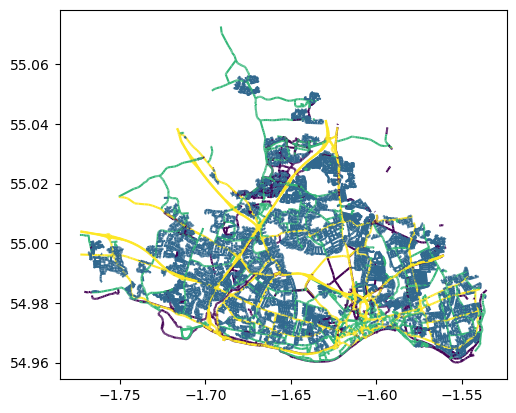

In [26]:
edges_base.plot(column="lts")

Chris says: 
> in external/data/newcastle/insert_scenario_here/  , they've got a column called "total_flow" which is the number of trips between the start and end points. start_osmid and end_osmid are the OSM node ids

In [27]:
mydemand.head()

,start_osmid,end_osmid,distance,sp_lts_route,sp_lts_distance,sp_true_distance,eucl_dist,ltn_origin,ltn_destination,start_norm,end_norm,osmid_pair,total_flow_x,total_flow_y,total_flow,geometry
0,826287045,1907450682,309.249812,None,445.726,445.726,309.249812,True,True,826287045,1907450682,None,15.702733,15.702733,15.702733,"LINESTRING (-1.62488 54.96771, -1.62136 54.96961)"
1,12091933082,4140896891,366.611193,None,1035.100,1035.100,366.611193,True,True,4140896891,12091933082,None,18.276293,18.276293,18.276293,"LINESTRING (-1.61558 54.97912, -1.61032 54.98041)"
2,2392633844,12091933082,406.684872,None,847.536,847.536,406.684872,True,True,2392633844,12091933082,None,16.762135,16.762135,16.762135,"LINESTRING (-1.61332 54.97571, -1.61558 54.97912)"
3,29013257,252100827,415.313673,None,1326.051,1326.051,415.313673,True,True,29013257,252100827,None,34.544636,34.544636,34.544636,"LINESTRING (-1.61430 55.00879, -1.61068 55.01189)"
4,776327170,345643357,481.877848,None,676.124,676.124,481.877848,True,True,345643357,776327170,None,29.505117,29.505117,29.505117,"LINESTRING (-1.58216 54.97811, -1.58948 54.97912)"


In [28]:
assert all([n in G_base.nodes for n in mydemand.start_osmid])
assert all([n in G_base.nodes for n in mydemand.end_osmid])

In [40]:
mydemand

,start_osmid,end_osmid,distance,sp_lts_route,sp_lts_distance,sp_true_distance,eucl_dist,ltn_origin,ltn_destination,start_norm,end_norm,osmid_pair,total_flow_x,total_flow_y,total_flow,geometry
0,826287045,1907450682,309.249812,None,445.726,445.726,309.249812,True,True,826287045,1907450682,None,15.702733,15.702733,15.702733,"LINESTRING (-1.62488 54.96771, -1.62136 54.96961)"
1,12091933082,4140896891,366.611193,None,1035.100,1035.100,366.611193,True,True,4140896891,12091933082,None,18.276293,18.276293,18.276293,"LINESTRING (-1.61558 54.97912, -1.61032 54.98041)"
2,2392633844,12091933082,406.684872,None,847.536,847.536,406.684872,True,True,2392633844,12091933082,None,16.762135,16.762135,16.762135,"LINESTRING (-1.61332 54.97571, -1.61558 54.97912)"
3,29013257,252100827,415.313673,None,1326.051,1326.051,415.313673,True,True,29013257,252100827,None,34.544636,34.544636,34.544636,"LINESTRING (-1.61430 55.00879, -1.61068 55.01189)"
4,776327170,345643357,481.877848,None,676.124,676.124,481.877848,True,True,345643357,776327170,None,29.505117,29.505117,29.505117,"LINESTRING (-1.58216 54.97811, -1.58948 54.97912)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,2380320060,11788085686,3161.810106,None,5512.792,5512.792,3161.810106,True,False,2380320060,11788085686,None,0.000000,NaN,0.000000,"LINESTRING (-1.66746 55.01830, -1.71609 55.01321)"
229,9189962716,11788085686,3345.817222,None,6537.140,6537.140,3345.817222,True,False,9189962716,11788085686,None,0.000000,NaN,0.000000,"LINESTRING (-1.76174 54.99856, -1.71609 55.01321)"
230,1069450638,778308101,3507.387712,None,3902.605,3902.605,3507.387712,False,False,778308101,1069450638,None,1.797237,1.797237,1.797237,"LINESTRING (-1.60487 54.97124, -1.55257 54.96190)"
231,2380320060,865262083,3639.876111,None,4893.533,4893.533,3639.876111,True,False,865262083,2380320060,None,1.674931,1.674931,1.674931,"LINESTRING (-1.66746 55.01830, -1.67907 55.05031)"


**Route on network (for G_base and G_curr)**

@CHRIS: where does the lts_distance come from? should i use the same?

strategy:
1. convert networkx object to igraph for faster shortest path comps
2. find shortest paths based on weight; where weight = length * LTS-factor
3. save shortest paths as igraph edge lists, one for each OD pair
4. evaluate "bikeability" based on:

        a. cut-off for total trip length (sum of edge lengths) UNDER 10KM
        b. detour (trip length over shortest naive path length) >> can i use "sp_true_distance"? UNDER 1.5 DETOUR RATIO
        c. average lts (weighted by length) UNDER AVG LTS 2

## PICKING UP HERE
now route on G_base; then create G_curr that has added edges; route again; compute bikeabilities

In [29]:
G_added = make_oxgraph_undirected_with_uv(G_added)
edges_added = ox.graph_to_gdfs(G_added, nodes=False)
edges_added = edges_added.reset_index(drop=True)
edges_added = edges_added.set_index("uv")
edges_added.head(3)

,osmid,maxspeed,highway,length,weight,geometry
uv,,,,,,
"(281477123, 8145693670)",333353633,0,cycleway,36.191,36.191,"LINESTRING (-1.58052 55.00151, -1.57999 55.00140)"
"(251426178, 281477123)",333353633,0,cycleway,19.647,19.647,"LINESTRING (-1.58052 55.00151, -1.58080 55.00159)"
"(939261960, 2389795960)",70717801,30,secondary,35.237,35.237,"LINESTRING (-1.68721 54.99816, -1.68773 54.99828)"


<Axes: >

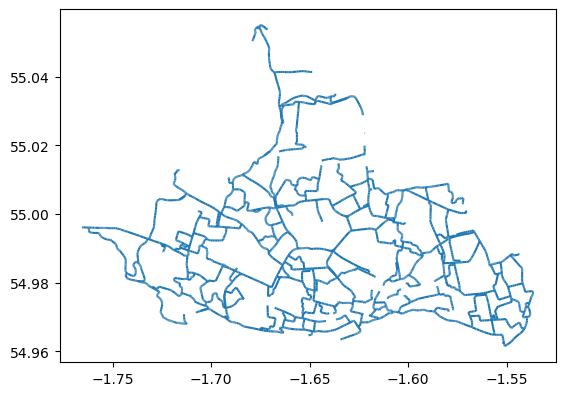

In [30]:
edges_added.plot()

@CHRIS: does this look right as edges-to-add?

Which one should be our "base" object?

Have you worked with igraph?

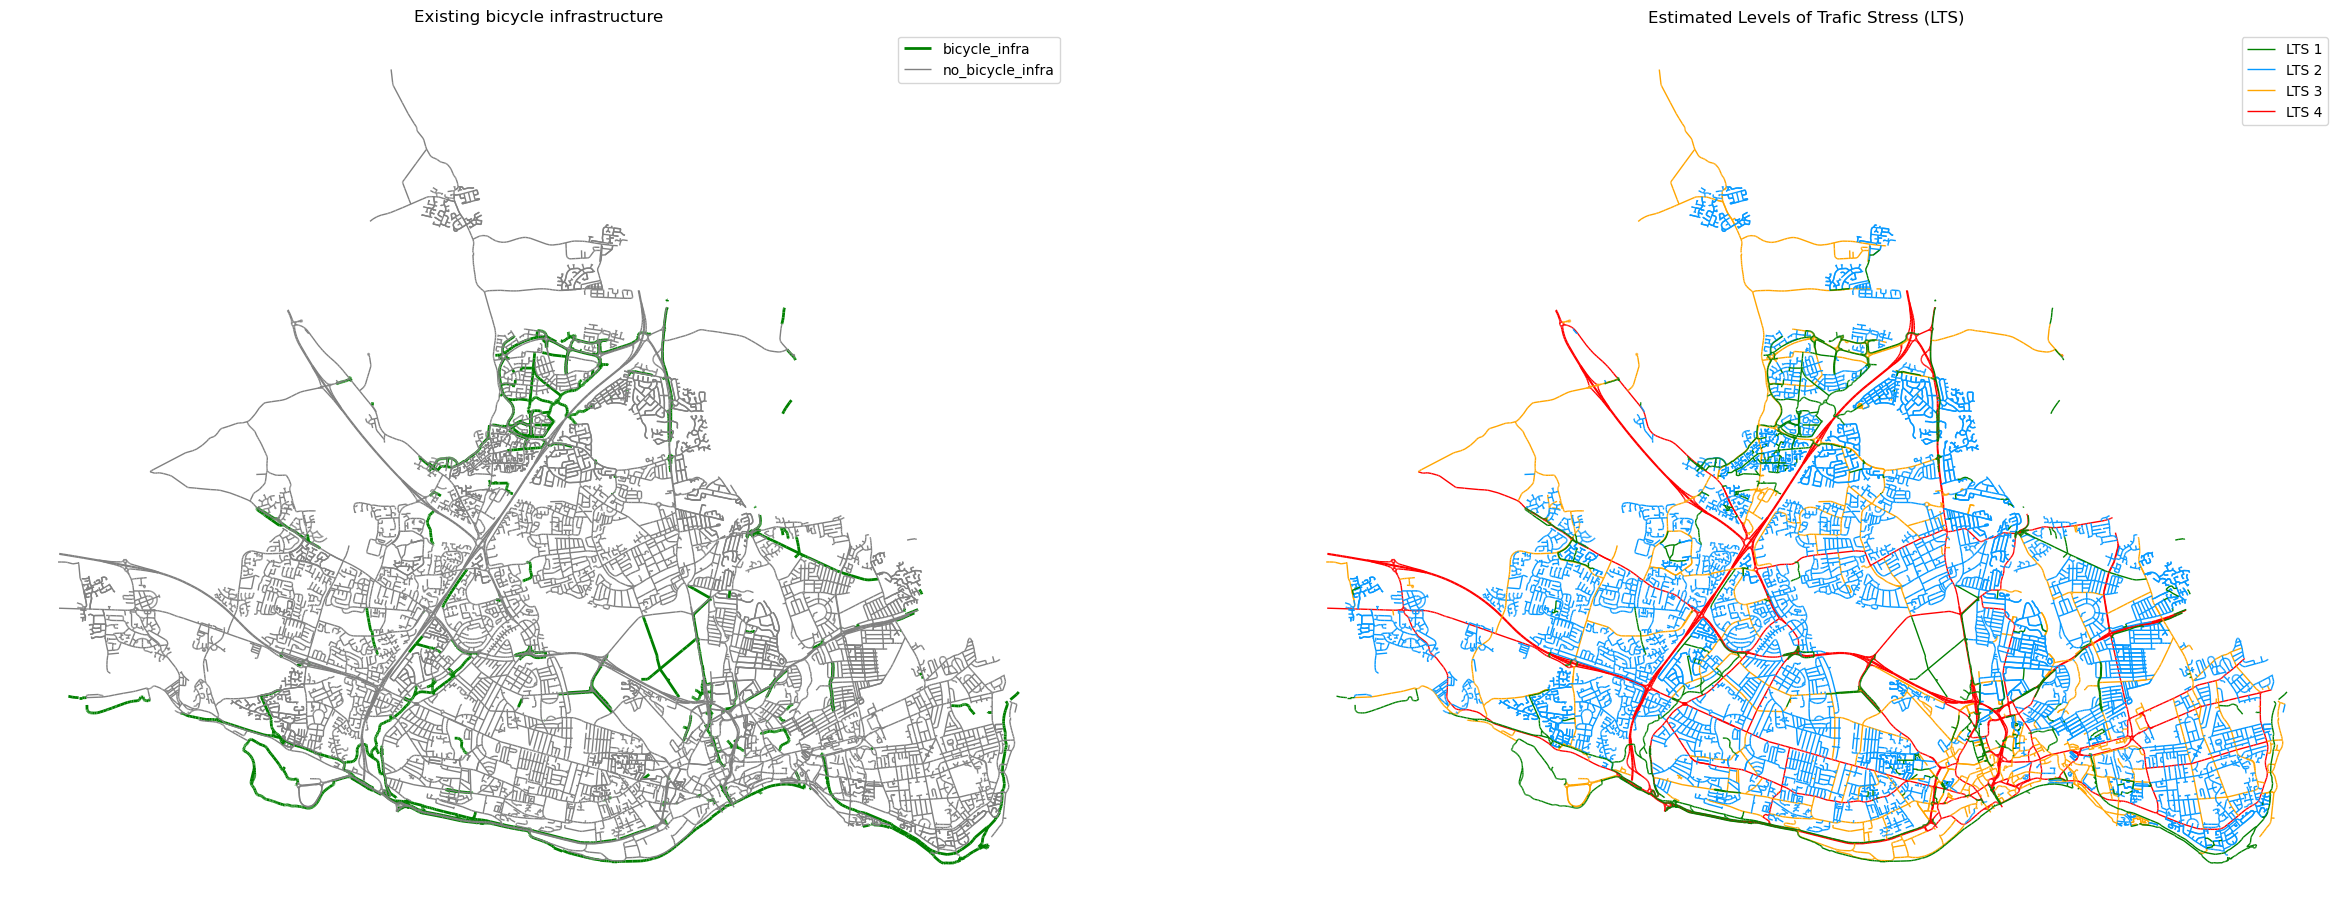

In [69]:
fig, axs = plt.subplots(1,2, figsize = (30,20))

# plot bicycle vs non bicycle infra
ax = axs[0]
edges_base[edges_base["bicycle_infra"]==True].plot(ax=ax, label = "bicycle_infra", color = "green", lw = 2)
edges_base[edges_base["bicycle_infra"]!=True].plot(ax=ax, label = "no_bicycle_infra", color = "grey", lw = 1)
ax.legend()
ax.set_axis_off()
ax.set_title("Existing bicycle infrastructure")

# plot by lts
ax = axs[1]
for lts in [1,2,3,4]:
    edges_base[edges_base["lts"]==lts].plot(
            ax=ax, 
            label=f"LTS {lts}",
            **plotparam[lts]
        )
ax.legend()
ax.set_axis_off()
ax.set_title("Estimated Levels of Trafic Stress (LTS)")
plt.show()

In [ ]:
mygraph = demand_results[myscenario][mylocation]["GTs"][-1]
mygraph.edges(data=False, keys=False)


OutMultiEdgeDataView([(281477123, 8145693670), (281477123, 251426178), (939261960, 2389795960), (939261960, 4748191312), (939261973, 2682651062), (939261973, 964970951), (7984447515, 8575633553), (7984447515, 59663052), (1164017705, 1164018039), (1164017714, 29677565), (1164017714, 1164017105), (1164017720, 1164018334), (1164017720, 1164016920), (1164017724, 3913552435), (1164017724, 1730408875), (281477183, 282479893), (281477183, 254945294), (281477193, 36138969), (281477193, 281477198), (281477195, 2682651085), (281477195, 281477198), (281477196, 9340581541), (281477196, 2682651089), (281477197, 2682651091), (281477197, 9340581541), (281477198, 281477195), (281477198, 281477193), (1164017749, 331536699), (281477207, 281477208), (281477207, 2682651091), (281477208, 281477212), (281477208, 281477207), (1307934808, 1397590899), (1307934808, 1397590903), (281477210, 2211959823), (281477210, 281477212), (1307934810, 2682650943), (1307934810, 776473142), (281477212, 281477210), (281477212